# 02 · Feature Engineering & Graph Features

Builds and inspects tabular features, engineers time-series features per card,
constructs the card-merchant bipartite graph, and saves all artefacts to `data/processed/`.

In [1]:
import warnings; warnings.filterwarnings("ignore")
from pathlib import Path
import gc, json, pickle, time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.sparse as sp
from sklearn.preprocessing import RobustScaler

%matplotlib inline
plt.rcParams.update({
    "figure.facecolor":"#0F1117","axes.facecolor":"#1A1D27","axes.edgecolor":"#2E3347",
    "text.color":"#E0E0E0","axes.labelcolor":"#E0E0E0","xtick.color":"#9AA0B0",
    "ytick.color":"#9AA0B0","grid.color":"#2E3347","grid.linestyle":"--",
    "font.family":"monospace","figure.dpi":120,
})
PAL = {"normal":"#4A90D9","fraud":"#E84545","accent":"#F5A623","purple":"#A259FF"}
print("Imports OK")


Imports OK


In [2]:
from pathlib import Path
# ── Change this to point to your repo root if running from elsewhere
REPO_ROOT = Path(".").resolve().parent  # assumes notebook is in notebooks/
DATA_DIR  = REPO_ROOT / "data" / "raw"
PROC_DIR  = REPO_ROOT / "data" / "processed"
MODEL_DIR = REPO_ROOT / "models"
OUT_DIR   = REPO_ROOT / "outputs"
for d in [PROC_DIR, MODEL_DIR, OUT_DIR]: d.mkdir(parents=True, exist_ok=True)
print(f"Data  : {DATA_DIR}")
print(f"Proc  : {PROC_DIR}")

Data  : /Users/MYOUSSF/Desktop/Projects/fraud_detection_project/data/raw
Proc  : /Users/MYOUSSF/Desktop/Projects/fraud_detection_project/data/processed


In [3]:
# ── Load raw data ─────────────────────────────────────────────────────────────
tx  = pd.read_csv(DATA_DIR / "train_transaction.csv")
idf = pd.read_csv(DATA_DIR / "train_identity.csv")
df  = tx.merge(idf, on="TransactionID", how="left")
df  = df.rename(columns={"isFraud":"Class","TransactionAmt":"Amount","TransactionDT":"Time"})
df["user_id"] = df["card1"].fillna(0).astype(int)
df  = df.sort_values(["user_id","Time"]).reset_index(drop=True)
del tx, idf; gc.collect()
print(f"Loaded: {df.shape}")


Loaded: (590540, 435)


In [4]:
# ── Train / test split (stratified on TransactionID) ─────────────────────────
from sklearn.model_selection import train_test_split

all_txids = df["TransactionID"].values
labels    = df["Class"].values.astype(np.int8)
tr_idx, te_idx = train_test_split(np.arange(len(df)), test_size=0.2,
                                   random_state=42, stratify=labels)
train_txids = set(all_txids[tr_idx].tolist())
test_txids  = set(all_txids[te_idx].tolist())
print(f"Train: {len(train_txids):,}  Test: {len(test_txids):,}")
print(f"Train fraud: {labels[tr_idx].mean()*100:.3f}%  Test fraud: {labels[te_idx].mean()*100:.3f}%")


Train: 472,432  Test: 118,108
Train fraud: 3.499%  Test fraud: 3.499%


## 1 · Tabular feature engineering

In [5]:
N_V = 28
v_feats = [f"V{i}" for i in range(1, N_V+1)]
for i in range(1, N_V+1):
    if f"V{i}" not in df.columns:
        df[f"V{i}"] = 0.0

df["log_amount"]          = np.log1p(df["Amount"].fillna(0))
df["time_delta"]          = df.groupby("user_id")["Time"].diff().fillna(0)
df["rolling_amount_mean_3"] = df.groupby("user_id")["log_amount"].transform(
    lambda x: x.rolling(3, min_periods=1).mean())
df["amount_vs_mean"]      = df["log_amount"] - df["rolling_amount_mean_3"]

ENGINEERED    = ["log_amount","time_delta","rolling_amount_mean_3","amount_vs_mean"]
feature_names = v_feats + ENGINEERED
df[feature_names] = df[feature_names].fillna(0)
print(f"Feature columns: {len(feature_names)}  ({N_V} V + {len(ENGINEERED)} engineered)")


Feature columns: 32  (28 V + 4 engineered)


In [6]:
# ── Scale ─────────────────────────────────────────────────────────────────────
mask_train_normal = df["TransactionID"].isin(train_txids) & (df["Class"] == 0)
scaler = RobustScaler()
scaler.fit(df.loc[mask_train_normal, feature_names])
df[feature_names] = scaler.transform(df[feature_names])

with open(PROC_DIR / "scaler.pkl", "wb") as fh: pickle.dump(scaler, fh)
print(f"Scaler fitted on {mask_train_normal.sum():,} training-normal rows → saved")

X = np.clip(df[feature_names].values, -5, 5).astype(np.float32)
y = df["Class"].values.astype(np.int8)
tx_ids = df["TransactionID"].values.astype(np.int64)
tx_dt  = df["Time"].values.astype(np.float64)

tr_mask = np.isin(tx_ids, np.fromiter(train_txids, dtype=np.int64))
te_mask = np.isin(tx_ids, np.fromiter(test_txids,  dtype=np.int64))

np.save(PROC_DIR/"X_train_tab_all.npy",  X[tr_mask])
np.save(PROC_DIR/"X_test_tab.npy",       X[te_mask])
np.save(PROC_DIR/"y_train_all.npy",      y[tr_mask])
np.save(PROC_DIR/"y_test.npy",           y[te_mask])
np.save(PROC_DIR/"tx_ids_train_all.npy", tx_ids[tr_mask])
np.save(PROC_DIR/"tx_ids_test_tab.npy",  tx_ids[te_mask])
np.save(PROC_DIR/"tx_dt_train.npy",      tx_dt[tr_mask])
np.save(PROC_DIR/"tx_dt_test.npy",       tx_dt[te_mask])

meta = {"n_features":len(feature_names),"features":feature_names,
        "train_size":int(tr_mask.sum()),"test_size":int(te_mask.sum()),
        "train_fraud":int(y[tr_mask].sum()),"test_fraud":int(y[te_mask].sum())}
with open(PROC_DIR/"feature_meta.json","w") as fh: json.dump(meta, fh, indent=2)
print(f"Saved — train: {tr_mask.sum():,}  test: {te_mask.sum():,}")


Scaler fitted on 455,902 training-normal rows → saved
Saved — train: 472,432  test: 118,108


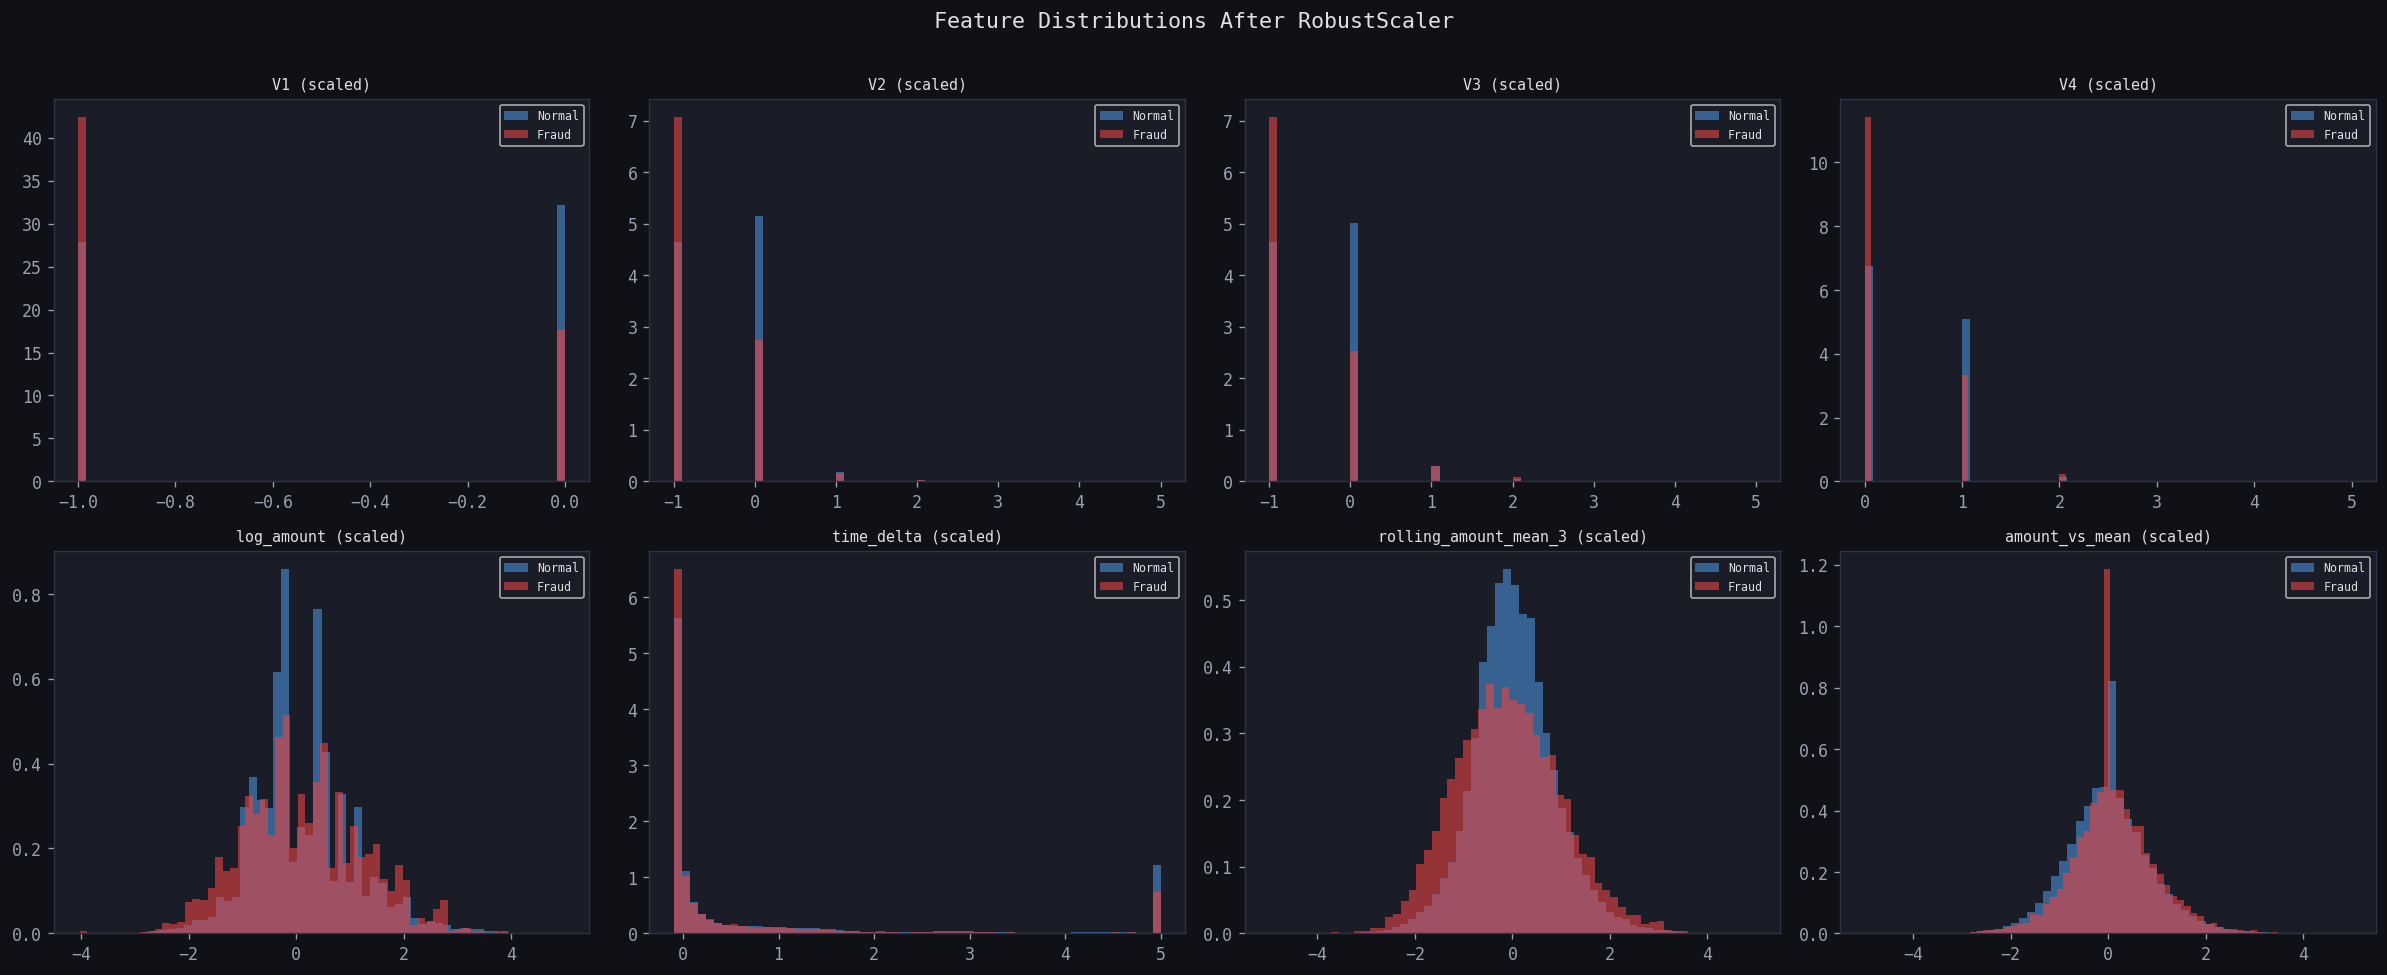

In [7]:
# ── Feature distribution after scaling ───────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
fig.patch.set_facecolor("#0F1117")
sample_feats = v_feats[:4] + ENGINEERED
X_tr = np.load(PROC_DIR/"X_train_tab_all.npy")
y_tr = np.load(PROC_DIR/"y_train_all.npy")
feat_idx = {f: i for i, f in enumerate(feature_names)}
for ax, feat in zip(axes.flat, sample_feats):
    idx_f = feat_idx[feat]
    for cls, lbl, col in [(0,"Normal",PAL["normal"]),(1,"Fraud",PAL["fraud"])]:
        vals = X_tr[y_tr==cls, idx_f]
        ax.hist(vals, bins=60, alpha=0.6, color=col, label=lbl, density=True)
    ax.set_title(f"{feat} (scaled)", color="#E0E0E0", fontsize=9)
    ax.legend(fontsize=7)
plt.suptitle("Feature Distributions After RobustScaler", fontsize=13, color="#E0E0E0", y=1.01)
plt.tight_layout(); plt.show()


## 2 · Graph feature construction

In [8]:
GRAPH_FEATURES = ["g_card_degree","g_card_weighted_degree","g_clustering",
                  "g_pagerank","g_avg_amount","g_amount_var","g_merchant_diversity"]
MAX_MERCH = 500; PR_ALPHA = 0.85; PR_ITERS = 100; PR_TOL = 1e-6

df["card_id"]    = df["card1"].fillna(0).astype(int)
df["merchant_id"] = (df["ProductCD"].fillna("X").astype(str)+"_"+
                     df["card4"].fillna("unk").astype(str)+"_M")
df["log_amount"] = np.log1p(df["Amount"].fillna(0))
df = df.sort_values("Time").reset_index(drop=True)

cards = df["card_id"].unique()
card_to_idx = {c:i for i,c in enumerate(cards)}
n_cards = len(cards)
print(f"Unique cards: {n_cards:,}")


Unique cards: 13,553


In [9]:
# Step 1: pandas metrics
print("Step 1: pandas metrics ...")
df_train      = df[df["TransactionID"].isin(train_txids)]
wdeg_train    = df_train.groupby("card_id").size()
degree_s      = df.groupby("card_id")["merchant_id"].nunique()
wdeg_s        = df.groupby("card_id").size()
amt_stats     = df.groupby("card_id")["log_amount"].agg(["mean","var"])
degree_dict   = degree_s.to_dict()
weighted_deg  = wdeg_s.to_dict()
avg_amt       = amt_stats["mean"].fillna(0).to_dict()
amt_var       = amt_stats["var"].fillna(0).to_dict()
merch_div     = {c: degree_dict.get(c,0)/max(weighted_deg.get(c,1),1) for c in cards}
del df_train, wdeg_train, degree_s, wdeg_s, amt_stats
print("  done")


Step 1: pandas metrics ...
  done


In [10]:
# Step 2: sparse adjacency
print("Step 2: sparse adjacency ...")
merchant_groups = df.groupby("merchant_id")["card_id"].apply(list)
rows_l, cols_l = [], []
for mc in merchant_groups:
    idxs = [card_to_idx[c] for c in mc if c in card_to_idx]
    if len(idxs) < 2 or len(idxs) > MAX_MERCH: continue
    for a in range(len(idxs)):
        for b in range(a+1, len(idxs)):
            rows_l.extend([idxs[a], idxs[b]])
            cols_l.extend([idxs[b], idxs[a]])
del merchant_groups
rows, cols = np.array(rows_l, dtype=np.int32), np.array(cols_l, dtype=np.int32)
del rows_l, cols_l
A = sp.csr_matrix(sp.coo_matrix(
    (np.ones(len(rows), dtype=np.float32), (rows, cols)), shape=(n_cards, n_cards)))
A.data[:] = 1.0; A.eliminate_zeros()
del rows, cols
print(f"  adj shape={A.shape}  nnz={A.nnz:,}")


Step 2: sparse adjacency ...
  adj shape=(13553, 13553)  nnz=6,283


In [11]:
# Step 3: clustering + Step 4: PageRank
print("Step 3: clustering coefficients ...")
A2 = A.dot(A)
tri_arr = np.array(A.multiply(A2.T).sum(axis=1)).ravel() / 2
del A2
deg_arr = np.array(A.sum(axis=1)).ravel()
denom   = deg_arr * (deg_arr - 1)
with np.errstate(invalid="ignore"):
    cc_arr = np.where(denom > 0, 2.0*tri_arr/denom, 0.0).astype(np.float32)
del tri_arr, denom
print(f"  mean_cc={cc_arr.mean():.4f}")

print("Step 4: PageRank ...")
with np.errstate(divide="ignore"):
    deg_inv = np.where(deg_arr > 0, 1.0/deg_arr, 0.0)
del deg_arr

merch_groups2 = df.groupby("merchant_id")["card_id"].apply(list)
t_rows, t_cols, t_vals = [], [], []
for mc in merch_groups2:
    idxs = [card_to_idx[c] for c in mc if c in card_to_idx]
    if len(idxs) < 2 or len(idxs) > MAX_MERCH: continue
    for a in range(len(idxs)):
        for b in range(a+1, len(idxs)):
            t_rows.extend([idxs[b], idxs[a]])
            t_cols.extend([idxs[a], idxs[b]])
            t_vals.extend([deg_inv[idxs[a]], deg_inv[idxs[b]]])
del merch_groups2, deg_inv
T = sp.csr_matrix((np.array(t_vals,dtype=np.float64),
    (np.array(t_rows,dtype=np.int32),np.array(t_cols,dtype=np.int32))),
    shape=(n_cards,n_cards))
del t_rows,t_cols,t_vals
r = np.full(n_cards, 1.0/n_cards, dtype=np.float64)
for _ in range(PR_ITERS):
    r_new = PR_ALPHA*T.dot(r)+(1-PR_ALPHA)/n_cards
    if np.linalg.norm(r_new-r,1)<PR_TOL: break
    r = r_new
del T, r
pagerank = {cards[i]: float(r_new[i]) for i in range(n_cards)}
del r_new
print("  PageRank done")


Step 3: clustering coefficients ...
  mean_cc=0.0066
Step 4: PageRank ...
  PageRank done


In [12]:
# Assemble and save
def _lookup(d, keys, default=0.0):
    vals = np.array([d.get(k, default) for k in keys], dtype=np.float64)
    return np.clip(vals, np.finfo(np.float32).min, np.finfo(np.float32).max).astype(np.float32)

idx_arr = np.array([card_to_idx.get(c, 0) for c in df["card_id"].values], dtype=np.int32)
X_graph = np.column_stack([
    np.take(_lookup(degree_dict, cards), idx_arr),
    np.take(_lookup(weighted_deg, cards), idx_arr),
    np.take(cc_arr, idx_arr),
    np.take(_lookup(pagerank, cards), idx_arr),
    np.take(_lookup(avg_amt, cards), idx_arr),
    np.take(_lookup(amt_var, cards), idx_arr),
    np.take(_lookup(merch_div, cards), idx_arr),
])
del degree_dict,weighted_deg,cc_arr,pagerank,avg_amt,amt_var,merch_div,idx_arr,A

X_graph = np.nan_to_num(X_graph, nan=0.0, posinf=0.0, neginf=0.0)
tx_g  = df["TransactionID"].values; y_g = df["Class"].values.astype(np.int8)
tr_mask_g = np.array([tid in train_txids for tid in tx_g])
te_mask_g = np.array([tid in test_txids  for tid in tx_g])

gs = RobustScaler()
X_graph[tr_mask_g] = gs.fit_transform(X_graph[tr_mask_g])
X_graph[te_mask_g] = gs.transform(X_graph[te_mask_g])
X_graph = np.clip(X_graph, -10.0, 10.0)

np.save(PROC_DIR/"graph_features_train.npy",  X_graph[tr_mask_g])
np.save(PROC_DIR/"graph_features_test.npy",   X_graph[te_mask_g])
np.save(PROC_DIR/"graph_tx_ids_train.npy",    tx_g[tr_mask_g])
np.save(PROC_DIR/"graph_tx_ids_test.npy",     tx_g[te_mask_g])
np.save(PROC_DIR/"y_graph_train.npy",         y_g[tr_mask_g])
np.save(PROC_DIR/"y_graph_test.npy",          y_g[te_mask_g])
with open(PROC_DIR/"graph_scaler.pkl","wb") as fh: pickle.dump(gs, fh)
with open(PROC_DIR/"graph_meta.json","w") as fh:
    json.dump({"graph_features":GRAPH_FEATURES,"n_features":len(GRAPH_FEATURES)}, fh, indent=2)

print(f"Saved graph — train: {tr_mask_g.sum():,}  test: {te_mask_g.sum():,}")
gc.collect()


Saved graph — train: 472,432  test: 118,108


87

## 3 · Graph feature inspection

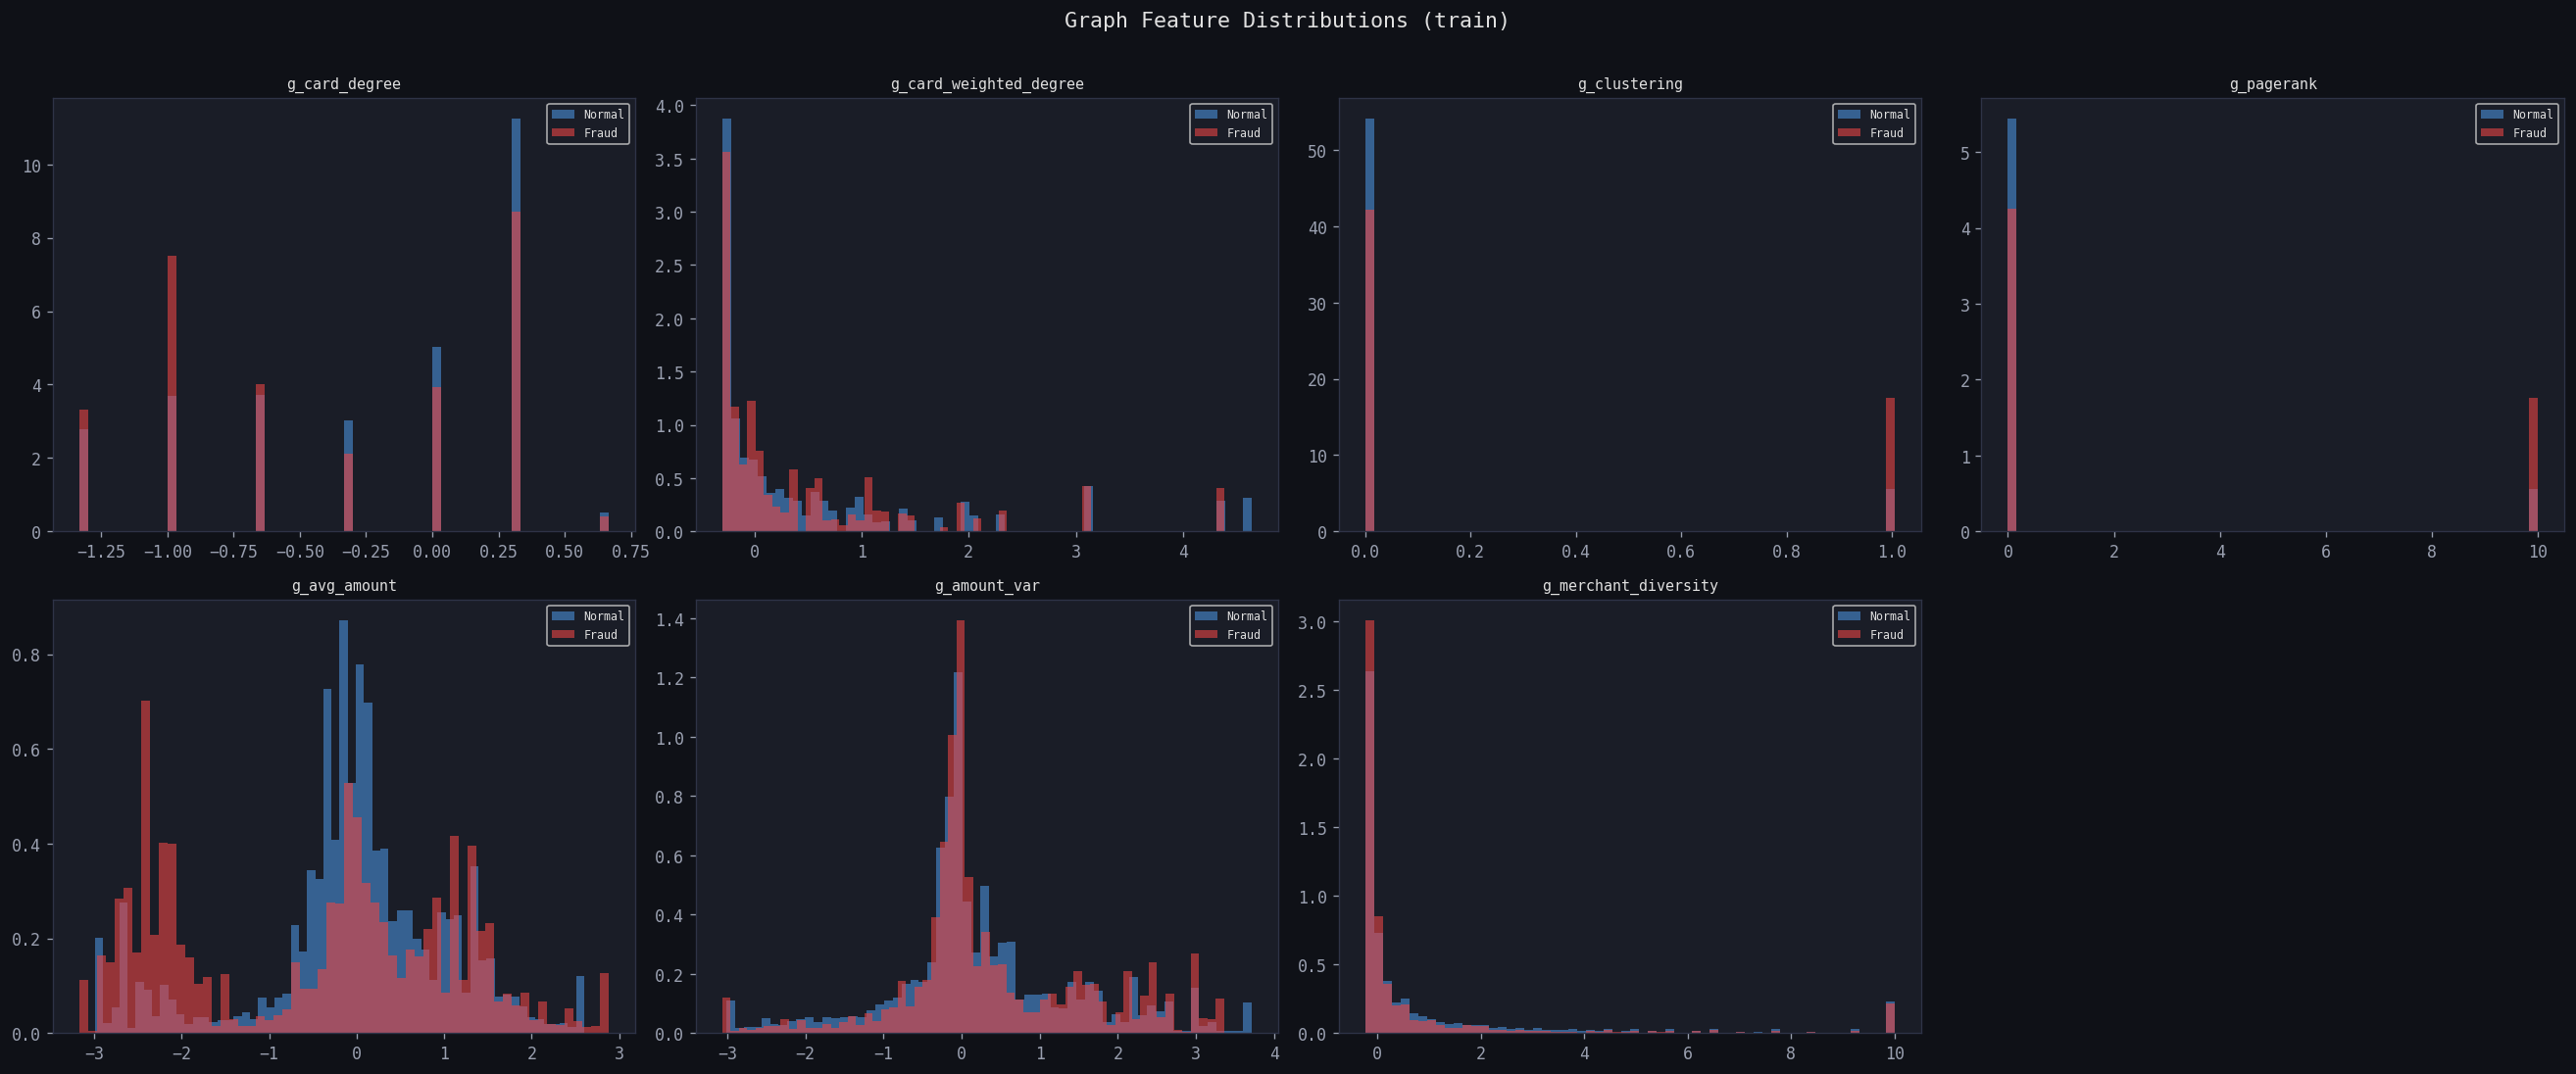

In [13]:
G_tr = np.load(PROC_DIR/"graph_features_train.npy")
y_tr = np.load(PROC_DIR/"y_graph_train.npy")

fig, axes = plt.subplots(2, 4, figsize=(22, 9))
fig.patch.set_facecolor("#0F1117")
for ax, feat, idx in zip(axes.flat, GRAPH_FEATURES, range(len(GRAPH_FEATURES))):
    for cls, lbl, col in [(0,"Normal",PAL["normal"]),(1,"Fraud",PAL["fraud"])]:
        vals = G_tr[y_tr==cls, idx]
        lo,hi = np.percentile(vals,1), np.percentile(vals,99)
        ax.hist(vals.clip(lo,hi), bins=60, alpha=0.6, color=col, label=lbl, density=True)
    ax.set_title(feat, color="#E0E0E0", fontsize=9)
    ax.legend(fontsize=7)
axes.flat[-1].set_visible(False)
plt.suptitle("Graph Feature Distributions (train)", fontsize=13, color="#E0E0E0", y=1.01)
plt.tight_layout(); plt.show()


In [14]:
# Graph feature fraud separation (KS test)
from scipy import stats as scipy_stats
print(f"{'Feature':<30} {'KS stat':>8} {'Normal mean':>12} {'Fraud mean':>12}")
print("-"*65)
for i, feat in enumerate(GRAPH_FEATURES):
    a = G_tr[y_tr==0, i]; b = G_tr[y_tr==1, i]
    ks, _ = scipy_stats.ks_2samp(a, b)
    print(f"{feat:<30} {ks:>8.4f} {a.mean():>12.4f} {b.mean():>12.4f}")


Feature                         KS stat  Normal mean   Fraud mean
-----------------------------------------------------------------
g_card_degree                    0.1552      -0.2266      -0.4047
g_card_weighted_degree           0.0536       0.5360       0.4675
g_clustering                     0.1989       0.0940       0.2939
g_pagerank                       0.1989       0.9354       2.9244
g_avg_amount                     0.2569      -0.0265      -0.4858
g_amount_var                     0.0573       0.2818       0.4169
g_merchant_diversity             0.0963       1.0329       0.8113


In [15]:
print("\nAll artefacts in processed/:")
for p in sorted(PROC_DIR.glob("*")):
    size = p.stat().st_size / 1024**2
    print(f"  {p.name:<40} {size:6.1f} MB")



All artefacts in processed/:
  X_test_tab.npy                             14.4 MB
  X_train_normal.npy                         63.7 MB
  X_train_tab_all.npy                        57.7 MB
  feature_meta.json                           0.0 MB
  feature_names.npy                           0.0 MB
  graph_features_test.npy                     3.2 MB
  graph_features_train.npy                   12.6 MB
  graph_meta.json                             0.0 MB
  graph_scaler.pkl                            0.0 MB
  graph_tx_ids_test.npy                       0.9 MB
  graph_tx_ids_train.npy                      3.6 MB
  lgb_scores_test.npy                         0.9 MB
  lgb_tx_ids_test.npy                         0.9 MB
  scaler.pkl                                  0.0 MB
  sequence_meta.json                          0.0 MB
  shap_feature_names.npy                      0.0 MB
  shap_sample_idx.npy                         0.0 MB
  shap_values.npy                             0.6 MB
  test_score_txi